### описание проекта

Цель проекта. Обучить модель классификации животных на фотографиях с камер-ловушек из сегмента СНГ.

Проблема. Для СНГ почти нет данных. Из открытых источников удалось найти только один открытый датасет с фотоловушек, расположенных в СНГ-сегменте — RedForest, снимки из чернобыльской зоны: около 4 тысяч фотографий, порядка 10 видов. В датасете RedForest множество групп фотографий сделаны во время одной встречи с животным, из-за чего модель, обученная только на этом датасете, потеряет обобщающую способность и будет хуже классифиировать животных из других точек сегмента.

Есть очевидный путь закрыть нехватку данных — собрать свой датасет под задачу и разметить его вручную, как это сделали в проекте по фауне Карелии (~6700 фотографий, 8 уникальных видов животных, профессиональная разметка). Но такой датасет в открытом доступе не публиковался, а повторить его формирование без ресурсов на съёмку и разметку не получится. Открытого датасета уровня зарубежных Snapshot Serengeti или iWildCam для СНГ на сегодняшний день нет.

Гипотеза. Поскольку нет возможности провести разметку данных из требуемого сегмента, можно взять примеры из другого сегмента, обработать их и добавить в обучающую выборку (адаптировать домен) и получить модель, способную лучше классифицировать исходный домен, чем модель, обученная только на исходном домене. В качестве смежного домена выбран iNaturalist из-за большого количества фотографий по представленным в RedForest видам животных. Однако, в iNaturalist, в большей степени, приведены фотографии не с камер-ловушек, а сделанные людьми. Также в домене iNaturalist представлены фотографии следов присутствия животных, а не самих животных, ввиду чего требуется дополнительная предобработка данных. 

Метрика успеха. Модель, обученная на объединении доменов (iNaturalist + RedForest), должна классифицировать отложенную выборку RedForest заметно лучше, чем модель, обученная только на RedForest или обученная только на iNaturalist.

Основная метрика. В качестве основной метрики выбран weighted avg F1-score. Сделан такой выбор, поскольку этот скор учитывает precision и recall по каждому классу и точнее отражает качество классификации в условиях присутствующего дисбаланса классов: часть видов представлена тысячами фотографий, часть — менее чем тремя десятками. Веса в weighted avg F1 соответствуют распределению видов в тестовой выборке, что соотносится с постановкой задачи — на фотоловушках редкие виды будут давать меньше кадров, чем популярные виды.

Приведенный ноутбук разделен на блоки, каждый блок имеет пояснение, какую логику он представляет

### imports

тут импорты всех требуемых пакетов, установка рандом стейтов и инициализация девайса

In [1]:
import ast
import json
import os
import shutil
import random
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

from megadetector.detection.run_detector import load_detector
from transformers import AutoModel, AutoImageProcessor
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

from pytorch_metric_learning import losses, miners

/home/golubev.dmitriy25/venvs/experement_cv_venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# здесь фиксируем рандом стейты, чтобы была возможность воспроизвести эксперимен
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [3]:
# пути к директориям

EXPERIMENT_DIR: str = "/home/golubev.dmitriy25/datasets/experement/"
IMG_SAVE_DIR: str = "/home/golubev.dmitriy25/"

REDFOREST_DIR: str = EXPERIMENT_DIR + "redforest_val"
REDFOREST_CROPPED_DIR: str = EXPERIMENT_DIR + "redforest_cropped"
CHECKPOINT_PATH_RF: str = EXPERIMENT_DIR + "redforest_megadetector_results.csv"

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device", device)

using device cuda


### вспомогательные универсальные методы

во время рефакторинга я выделил повторяющиеся части кода и решил вынести их в отдельный блок, чтобы не раздувать и без того большой ноутбук

In [637]:
def plot_confusion_matrix(labels, preds, class_names, label_indices=None, title=None, 
                          save_name="confusion_matrix.png", figsize=(12, 10), save_dir=IMG_SAVE_DIR):
    cm = confusion_matrix(labels, preds, labels=label_indices)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=class_names,
        yticklabels=class_names,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    if title:
        plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{save_dir}{save_name}", dpi=200, bbox_inches="tight")
    plt.close()

    return cm 

### подготовка данных домена iNaturalist

первичная подготовка данных домена inaturalist

In [478]:
target_species: list[str] = [
    "Panthera tigris altaica",   # амурский тигр
    "Panthera pardus orientalis",# дальневосточный леопард
    "Ursus arctos",              # бурый медведь
    "Canis lupus",               # волк
    "Vulpes vulpes",             # лисица
    "Lynx lynx",                 # рысь
    "Gulo gulo",                 # росомаха
    "Meles meles",               # барсук
    "Capreolus pygargus",        # косуля
    "Cervus elaphus",            # благородный олень
    "Alces alces",               # лось
    "Sus scrofa",                # кабан
    "Rangifer tarandus",         # северный олень
    "Lepus timidus",             # заяц-беляк
    "Mustela sibirica",          # колонок
    "Nyctereutes procyonoides",  # енотовидная собака
    "Sciurus vulgaris",          # белка
    "Martes zibellina",          # соболь
]

In [479]:
taxa_df: pd.DataFrame = pd.read_csv(EXPERIMENT_DIR + "inaturalist-open-data-20260627/taxa.csv", sep="\t")
target_taxon_ids = set(
    taxa_df[taxa_df["name"].isin(target_species)]["taxon_id"]
)

In [480]:
CHUNKSIZE: int = 100_000  
filtered_chunks: list = []

for chunk in pd.read_csv(
    EXPERIMENT_DIR + "inaturalist-open-data-20260627/observations.csv",
    sep="\t",
    chunksize=CHUNKSIZE,
    usecols=["observation_uuid", "taxon_id", "latitude", "longitude", "quality_grade"],
    low_memory=False
):
    mask = (
        chunk["taxon_id"].isin(target_taxon_ids) &
        (chunk["quality_grade"] == "research")
    )
    filtered_chunks.append(chunk[mask])

filtered_obs = pd.concat(filtered_chunks, ignore_index=True)
print("total cases found -", len(filtered_obs))

total cases found - 267877


In [482]:
target_obs_uuids = set(filtered_obs["observation_uuid"])

photo_chunks = []
for chunk in pd.read_csv(
    EXPERIMENT_DIR + "inaturalist-open-data-20260627/photos.csv",
    sep="\t",
    chunksize=CHUNKSIZE,
    usecols=["photo_id", "extension", "observation_uuid"],
    low_memory=False
):
    photo_chunks.append(chunk[chunk["observation_uuid"].isin(target_obs_uuids)])

photos_filtered = pd.concat(photo_chunks, ignore_index=True)
print("total images accessed to download -", len(photos_filtered))

total images accessed to download - 484446


In [483]:
photos_filtered = photos_filtered.merge(
    filtered_obs[["observation_uuid", "taxon_id"]],
    on="observation_uuid"
)
photos_filtered = photos_filtered.merge(
    taxa_df[["taxon_id", "name"]],
    on="taxon_id"
)

photos_filtered.groupby("name").size().sort_values(ascending=False)

name
Vulpes vulpes                 163161
Sciurus vulgaris              113112
Alces alces                    63098
Sus scrofa                     53166
Cervus elaphus                 22701
Meles meles                    20427
Canis lupus                    10217
Ursus arctos                    9220
Lepus timidus                   7467
Capreolus pygargus              7264
Rangifer tarandus               6862
Nyctereutes procyonoides        3338
Lynx lynx                       1536
Gulo gulo                       1181
Mustela sibirica                1024
Panthera tigris altaica          398
Martes zibellina                 208
Panthera pardus orientalis        66
dtype: int64

In [484]:
obs_level = (
    photos_filtered
    .groupby("observation_uuid")
    .agg(
        photo_id=("photo_id", "first"),
        extension=("extension", "first"),
        taxon_id=("taxon_id", "first"),
        name=("name", "first"),
    )
    .reset_index()
)

obs_level.groupby("name").size().sort_values(ascending=False)

name
Vulpes vulpes                 87179
Sciurus vulgaris              63346
Alces alces                   36498
Sus scrofa                    30265
Cervus elaphus                12957
Meles meles                   12191
Canis lupus                    5046
Ursus arctos                   5005
Rangifer tarandus              4168
Capreolus pygargus             3976
Lepus timidus                  3760
Nyctereutes procyonoides       1568
Lynx lynx                       611
Mustela sibirica                553
Gulo gulo                       392
Panthera tigris altaica         216
Martes zibellina                103
Panthera pardus orientalis       43
dtype: int64

In [485]:
HEAD_CAP = 2000  # с целью устранения дисбаланса ограничил потолок примеров на класс. все примеры, не вошедшие в это множество, будут отброшены
MIN_EXAMPLES = 100  # отбросил наиболее непопулярный класс

capped_parts = []

for species, group in obs_level.groupby("name"):
    n = len(group)
    if n < MIN_EXAMPLES:
        continue
        
    if n > HEAD_CAP:
        group = group.sample(n=HEAD_CAP, random_state=42)
    
    capped_parts.append(group)

balanced = pd.concat(capped_parts, ignore_index=True)

print(balanced.groupby("name").size().sort_values(ascending=False).head(20))

name
Alces alces                 2000
Canis lupus                 2000
Capreolus pygargus          2000
Cervus elaphus              2000
Lepus timidus               2000
Meles meles                 2000
Sus scrofa                  2000
Ursus arctos                2000
Rangifer tarandus           2000
Vulpes vulpes               2000
Sciurus vulgaris            2000
Nyctereutes procyonoides    1568
Lynx lynx                    611
Mustela sibirica             553
Gulo gulo                    392
Panthera tigris altaica      216
Martes zibellina             103
dtype: int64


In [486]:
normal_classes = balanced[balanced["name"].isin(counts[counts >= MIN_FOR_SPLIT].index)]

train_df, temp_df = train_test_split(
    normal_classes, test_size=0.2, stratify=normal_classes["name"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["name"], random_state=42
)

In [487]:
for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["split"] = split_name

full_split = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(full_split.groupby(["name", "split"]).size().unstack(fill_value=0))

split                     test  train  val
name                                      
Alces alces                200   1600  200
Canis lupus                200   1600  200
Capreolus pygargus         200   1600  200
Cervus elaphus             200   1600  200
Lepus timidus              200   1600  200
Lynx lynx                   61    489   61
Meles meles                200   1600  200
Mustela sibirica            56    442   55
Nyctereutes procyonoides   157   1254  157
Rangifer tarandus          200   1600  200
Sciurus vulgaris           200   1600  200
Sus scrofa                 200   1600  200
Ursus arctos               200   1600  200
Vulpes vulpes              200   1600  200


In [488]:
full_split.to_csv(EXPERIMENT_DIR + "full_split-dataset_manifest.csv", index=False)

### валидация картинок, где явно есть животное . домен iNaturalist

подгружаем изображения из inaturalist и прогоняем их через детектор

In [ ]:
BASE_DIR = EXPERIMENT_DIR + "data"

def download_row(row):
    photo_id, ext, species, split = row
    species_clean = species.replace(" ", "_")
    path = f"{BASE_DIR}/{split}/{species_clean}/{photo_id}.{ext}"
    
    if os.path.exists(path):
        return "skipped"
    
    os.makedirs(os.path.dirname(path), exist_ok=True)
    url = f"https://inaturalist-open-data.s3.amazonaws.com/photos/{photo_id}/medium.{ext}"
    
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            with open(path, "wb") as f:
                f.write(r.content)
                
            return "ok"
            
        return f"http_{r.status_code}"
    
    except Exception as e:
        return f"error_{type(e).__name__}"

rows = list(
    full_split[["photo_id", "extension", "name", "split"]]
    .itertuples(index=False, name=None)
)

results = []
with ThreadPoolExecutor(max_workers=32) as ex:
    for res in tqdm(ex.map(download_row, rows), total=len(rows)):
        results.append(res)

Counter(results)

поскольку примеры в inaturalist зачастую содержат следы пребывания животного, а не само животное, было принято решение провести очистку датасета при помощи megadetector. можно сказать, аналог ручной разметки, после которого, в большинстве своем, останутся только те примеры, на которых и правда есть животное

In [489]:
# выбрал пятую версию мегадетектора, а не шестую, потому что пятая лучше себя показала при ручной оценке. 
# также в сети есть несколько статей-сравнений, в которых авторы приходят к выводу, что 6-я версия мегадетектора время от времени проигрывает пятой по тем или иным причинам
# поэтому я остановился на пятой версии
detector = load_detector("MDV5A")  

Model v5a.0.1 already exists and is valid at /tmp/megadetector_models/md_v5a.0.1.pt
PyTorch reports 1 available CUDA devices (load_detector)
Bypassing imports for model type yolov5
Loading PT detector with compatibility mode classic
Loaded image size 1280 from model metadata
Using model stride: 64
PTDetector using device cuda:0


Fusing layers... 
Fusing layers... 
Model summary: 733 layers, 140054656 parameters, 0 gradients
Model summary: 733 layers, 140054656 parameters, 0 gradients


In [490]:
# порог уверенности модели в том, что на кадре животное. подобран исходя из статьи https://wildeyeconservation.org/wp-content/uploads/2022/08/MDv5_Performance_Report.pdf - 
# там говорят про порог от 0.15 до 0.25 в таких сценариях
CONF_THRESHOLD = 0.2  
ANIMAL_CATEGORY = "1"   # категория мегадетектора для определения животного

results_log = []

In [503]:
full_split.head()

,observation_uuid,photo_id,extension,taxon_id,name,split
0,699dd9c1-d3c5-409f-a4ef-47a0d7555c35,424738628,png,55908.0,Lepus timidus,train
1,8186fb7b-9662-4a87-8b61-a146fb5332f7,470322743,jpeg,41979.0,Lynx lynx,train
2,7f545776-1789-478f-a47d-bef2e5d84f3b,598895988,jpg,41813.0,Mustela sibirica,train
3,66defd53-2c96-469c-96ce-8590e87b53df,466180157,jpeg,855297.0,Meles meles,train
4,98cda7db-78d5-42e1-91d3-7092792377a4,588047982,jpg,855311.0,Nyctereutes procyonoides,train


In [505]:
def run_detection(row):
    species_clean = row["name"].replace(" ", "_")
    path = f"{BASE_DIR}/{row['split']}/{species_clean}/{row['photo_id']}.{row['extension']}"
    
    if not os.path.exists(path):
        return None
    
    try:
        image = Image.open(path).convert("RGB")
        result = detector.generate_detections_one_image(image)
        
        animal_detections = [
            d for d in result["detections"] 
            if d["category"] == ANIMAL_CATEGORY and d["conf"] >= CONF_THRESHOLD
        ]
        
        has_animal = len(animal_detections) > 0
        max_conf = max([d["conf"] for d in animal_detections], default=0.0)
        best_bbox = animal_detections[0]["bbox"] if animal_detections else None
        
        return {
            "photo_id": row["photo_id"],
            "path": path,
            "has_animal": has_animal,
            "max_conf": max_conf,
            "bbox": best_bbox
        }
    except Exception as e:
        return {
            "photo_id": row["photo_id"],
            "path": path,
            "has_animal": None,
            "error": str(e)
        }

for _, row in tqdm(full_split.iterrows(), total=len(full_split)):
    res = run_detection(row)
    if res:
        results_log.append(res)

100%|██████████| 24732/24732 [33:26<00:00, 12.33it/s] 


In [506]:
detection_df = pd.DataFrame(results_log)
detection_df.to_csv("megadetector_results.csv", index=False)  # добавил чекпоинт с сохранением данных, чтобы не запускать пайплайн с нуля каждый раз

print("total processed: ", len(detection_df))
print("found photos with animals: ", detection_df['has_animal'].sum())
print("photos without animal :", (~detection_df['has_animal'].fillna(False)).sum())

total processed:  24728
found photos with animals:  21144
photos without animal : 3584


In [507]:
detection_df = pd.read_csv('megadetector_results.csv')
is_animal_df = detection_df[detection_df['has_animal'] == True]
temp_df = full_split[full_split['photo_id'].isin(is_animal_df['photo_id'].unique())]

temp_df['name'].value_counts()

name
Sciurus vulgaris            1934
Vulpes vulpes               1925
Cervus elaphus              1897
Rangifer tarandus           1808
Capreolus pygargus          1796
Sus scrofa                  1684
Meles meles                 1620
Lepus timidus               1610
Alces alces                 1565
Nyctereutes procyonoides    1466
Ursus arctos                1453
Canis lupus                 1448
Mustela sibirica             523
Lynx lynx                    415
Name: count, dtype: int64

### добавление данных из СНГ сегмента (redforest)

здесь идет обработка датасета redforest

In [508]:
rows = []
for species_dir in os.listdir(REDFOREST_DIR):
    species_path = os.path.join(REDFOREST_DIR, species_dir)
    if not os.path.isdir(species_path):
        continue
    
    for fname in os.listdir(species_path):
        if fname.lower().endswith((".jpg", ".jpeg")):
            rows.append({
                "path": os.path.join(species_path, fname),
                "name": species_dir,  
                "filename": fname
            })

redforest_manifest = pd.DataFrame(rows)
print("total records -", len(redforest_manifest))
print(redforest_manifest.groupby("name").size().sort_values(ascending=False))

total records - 4761
name
Capreolus pygargus          1628
Alces alces                 1472
Cervus elaphus              1266
Vulpes vulpes                175
Canis lupus                   90
Nyctereutes procyonoides      36
Sus scrofa                    32
Meles meles                   29
Lynx lynx                     23
Sciurus vulgaris              10
dtype: int64


In [521]:
def run_detection_rf(row):
    path = row["path"]
    
    if not os.path.exists(path):
        return None
    
    try:
        image = Image.open(path).convert("RGB")
        result = detector.generate_detections_one_image(image)
        
        animal_detections = [
            d for d in result["detections"]
            if d["category"] == ANIMAL_CATEGORY and d["conf"] >= CONF_THRESHOLD
        ]
        
        has_animal = len(animal_detections) > 0
        max_conf = max([d["conf"] for d in animal_detections], default=0.0)
        best_bbox = animal_detections[0]["bbox"] if animal_detections else None
        
        return {
            "path": path,
            "name": row["name"],
            "has_animal": has_animal,
            "max_conf": max_conf,
            "bbox": best_bbox
        }
    except Exception as e:
        print(f"error on {path}: {e}")
        return {
            "path": path,
            "name": row["name"],
            "has_animal": None,
            "error": str(e)
        }

In [522]:
SAVE_EVERY: int = 1000

if os.path.exists(CHECKPOINT_PATH_RF):
    done_df = pd.read_csv(CHECKPOINT_PATH_RF)
    done_paths = set(done_df["path"])
    results_log_rf = done_df.to_dict("records")

else:
    done_paths = set()
    results_log_rf = []

remaining_rf = redforest_manifest[~redforest_manifest["path"].isin(done_paths)]

for i, (_, row) in enumerate(tqdm(remaining_rf.iterrows(), total=len(remaining_rf))):
    res = run_detection_rf(row)
    if res:
        results_log_rf.append(res)
    
    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(results_log_rf).to_csv(CHECKPOINT_PATH_RF, index=False)

detection_df_rf = pd.DataFrame(results_log_rf)
detection_df_rf.to_csv(CHECKPOINT_PATH_RF, index=False)

print("total processed -", len(detection_df_rf))
print("found photos with animals -", detection_df_rf['has_animal'].sum())
print("photos without animal -", (~detection_df_rf['has_animal'].fillna(False)).sum())

0it [00:00, ?it/s]

total processed - 4761
found photos with animals - 4499
photos without animal - 262


In [523]:
detection_df_rf[detection_df_rf['has_animal']]['name'].value_counts()

name
Capreolus pygargus          1600
Alces alces                 1316
Cervus elaphus              1213
Vulpes vulpes                166
Canis lupus                   86
Nyctereutes procyonoides      35
Sus scrofa                    30
Meles meles                   22
Lynx lynx                     21
Sciurus vulgaris              10
Name: count, dtype: int64

In [524]:
# в рамках одного из экспериментов возникла гипотеза, чт стоит оставлять только те изображения, где область bbox занимает определенный процент от всей фотографии. но эта теория себя не оправдала
# MIN_AREA = 0.04 
MIN_CONF = 0.2

def parse_bbox(bbox):
    if bbox is None or (isinstance(bbox, float)):  # нулевый bbox
        return None
        
    if isinstance(bbox, str):
        return ast.literal_eval(bbox)
        
    return bbox


def is_informative(row, min_area=MIN_AREA, min_conf=MIN_CONF):
    bbox = parse_bbox(row.get("bbox"))
    if bbox is None:
        
        return False  

    x, y, w, h = bbox
    area = w * h
    conf = row.get("max_conf", 0.0)

    # if area < min_area:
    #     return False
    
    if conf < min_conf:
        return False
        
    return True

detection_df_rf["is_informative"] = detection_df_rf.apply(is_informative, axis=1)

print("total redforest records -", len(detection_df_rf))
print("total records with some animal -", detection_df_rf['is_informative'].sum())
print("records without animals -", (~detection_df_rf['is_informative']).sum()) 

total redforest records - 4761
total records with some animal - 4499
records without animals - 262


In [525]:
redforest_informative = detection_df_rf[detection_df_rf["is_informative"]].copy()

capped_parts = []
for species, group in redforest_informative.groupby("name"):
    if len(group) > 500:
        group = group.sample(n=500, random_state=42)
    capped_parts.append(group)

redforest_informative = pd.concat(capped_parts, ignore_index=True)

redforest_netvklass = detection_df_rf[~detection_df_rf["is_informative"]].copy()
redforest_netvklass["original_name"] = redforest_netvklass["name"]
redforest_netvklass["name"] = "net_v_klassifikatore"  # записи, на которых не обнаружено животное

print(redforest_informative.groupby("name").size().sort_values(ascending=False))

name
Alces alces                 500
Capreolus pygargus          500
Cervus elaphus              500
Vulpes vulpes               166
Canis lupus                  86
Nyctereutes procyonoides     35
Sus scrofa                   30
Meles meles                  22
Lynx lynx                    21
Sciurus vulgaris             10
dtype: int64


### кроп изображения по найденному megadetecor боксу

здесь проводится обрезка изображений по найденному bbox. популярными видами в домене redforest являются олени, лоси и косули, которые между собой сильно похожи (олени похожи на лосей, а косули похожи на оленей). поэтому было принято решение добавить отступ, чтобы в кадр, на котором будет учиться модель, попадали и рога животного

In [526]:
CROPPED_DIR = EXPERIMENT_DIR + "data_cropped"

# отступ, который поможет различать рогатых
PADDING = 0.35

MIN_AREA = 0.04       
MIN_CONF = 0.24

In [533]:
def parse_bbox(bbox):
    if isinstance(bbox, str):
        return ast.literal_eval(bbox)
        
    return bbox

# я провел несколько экспериментов с форматом обрезки, и лучше всего себя показала обрезка, в результате которой остается квадратное изображение
def crop_square_by_bbox(image, bbox, padding=PADDING): # =0.3):  
    w, h = image.size
    x, y, bw, bh = bbox
    
    cx = (x + bw / 2) * w
    cy = (y + bh / 2) * h
    
    side = max(bw * w, bh * h) * (1 + padding)
    
    x1 = max(0, cx - side / 2)
    y1 = max(0, cy - side / 2)
    x2 = min(w, cx + side / 2)
    y2 = min(h, cy + side / 2)
    
    return image.crop((int(x1), int(y1), int(x2), int(y2)))


def is_informative(row, min_area=MIN_AREA, min_conf=MIN_CONF):
    bbox = row.get("bbox")
    if bbox is None or (isinstance(bbox, float)):  
        return False

    bbox = parse_bbox(bbox)
    x, y, w, h = bbox
    area = w * h
    conf = row.get("max_conf", row.get("conf", 0.0))

    if area < min_area:
        return False
        
    if conf < min_conf:
        return False
        
    return True


# clean_df = temp_df.copy()
clean_df = pd.merge(temp_df, is_animal_df, on='photo_id', how='inner')
clean_df["is_informative"] = clean_df.apply(is_informative, axis=1)

print("total inaturalist records -", len(clean_df))
print("total records with some animal -", clean_df['is_informative'].sum())
print("records without animals -", (~clean_df['is_informative']).sum())

total inaturalist records - 21146
total records with some animal - 12700
records without animals - 8446


In [534]:
clean_df.head()

,observation_uuid,photo_id,extension,taxon_id,name,...,path,has_animal,max_conf,bbox,is_informative
0,699dd9c1-d3c5-409f-a4ef-47a0d7555c35,424738628,png,55908.0,Lepus timidus,...,/home/golubev.dmitriy25/datasets/experement/da...,True,0.752,"[0.572, 0.6832, 0.0939, 0.1103]",False
1,8186fb7b-9662-4a87-8b61-a146fb5332f7,470322743,jpeg,41979.0,Lynx lynx,...,/home/golubev.dmitriy25/datasets/experement/da...,True,0.332,"[0.412, 0.4056, 0.0599, 0.096]",False
2,7f545776-1789-478f-a47d-bef2e5d84f3b,598895988,jpg,41813.0,Mustela sibirica,...,/home/golubev.dmitriy25/datasets/experement/da...,True,0.669,"[0.2699, 0.4834, 0.298, 0.1471]",True
3,66defd53-2c96-469c-96ce-8590e87b53df,466180157,jpeg,855297.0,Meles meles,...,/home/golubev.dmitriy25/datasets/experement/da...,True,0.340,"[0.0026, 0.004, 0.9946, 0.986]",True
4,98cda7db-78d5-42e1-91d3-7092792377a4,588047982,jpg,855311.0,Nyctereutes procyonoides,...,/home/golubev.dmitriy25/datasets/experement/da...,True,0.893,"[0.0, 0.216, 0.694, 0.4213]",True


In [535]:
# net_v_klassifikatore (НВК) - класс для записей-изображений, на которых представлены примеры, что не относятся к другим классам классификатора. в нашем случае - изображения фона
# сам класс ограничен до +- среднего знеачения всей выборки, чтобы не вызывать сильный перекос 
netvklass_df = clean_df[~clean_df["is_informative"]].copy()
netvklass_df["original_name"] = netvklass_df["name"] 
netvklass_df["name"] = "net_v_klassifikatore"

NETCLASS_CAP: int = 1000
if len(netvklass_df) > NETCLASS_CAP:
    netvklass_df = netvklass_df.groupby("split", group_keys=False).apply(
        lambda g: g.sample(n=min(len(g), int(NETCLASS_CAP * len(g) / len(netvklass_df))), random_state=42)
    )

informative_df = clean_df[clean_df["is_informative"]].copy()

In [596]:
# all_records = pd.concat([informative_df, netvklass_df], ignore_index=True)
all_records = informative_df.copy()

obs_level = (
    all_records
    .groupby("observation_uuid")
    .agg(
        photo_id=("photo_id", "first"),
        extension=("extension", "first"),
        path=("path", "first"),
        bbox=("bbox", "first"),
        max_conf=("max_conf", "first"),
        name=("name", "first"),
    )
    .reset_index()
)

print(obs_level.groupby("name").size().sort_values(ascending=False))

name
Sciurus vulgaris            1431
Vulpes vulpes               1215
Cervus elaphus              1073
Meles meles                 1060
Sus scrofa                  1054
Capreolus pygargus          1026
Rangifer tarandus            995
Alces alces                  958
Nyctereutes procyonoides     901
Lepus timidus                874
Canis lupus                  775
Ursus arctos                 745
Mustela sibirica             381
Lynx lynx                    212
dtype: int64


In [597]:
counts = obs_level["name"].value_counts()

tiny_classes = obs_level[obs_level["name"].isin(counts[counts < MIN_FOR_SPLIT].index)]

train_df, temp_df_split = train_test_split(
    obs_level, test_size=0.2, stratify=obs_level["name"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df_split, test_size=0.5, stratify=temp_df_split["name"], random_state=42
)

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    df["split"] = split_name

full_split_new = pd.concat([train_df, val_df, test_df], ignore_index=True)

final_input_df = full_split_new
print(final_input_df.groupby(["name", "split"]).size().unstack(fill_value=0))

split                     test  train  val
name                                      
Alces alces                 96    766   96
Canis lupus                 77    620   78
Capreolus pygargus         102    821  103
Cervus elaphus             108    858  107
Lepus timidus               88    699   87
Lynx lynx                   21    170   21
Meles meles                106    848  106
Mustela sibirica            38    305   38
Nyctereutes procyonoides    90    721   90
Rangifer tarandus          100    796   99
Sciurus vulgaris           143   1145  143
Sus scrofa                 105    843  106
Ursus arctos                75    596   74
Vulpes vulpes              121    972  122


In [598]:
def process_row(row):
    try:
        image = Image.open(row["path"]).convert("RGB")
        bbox = parse_bbox(row["bbox"])

        cropped = crop_square_by_bbox(image, bbox) 

        species_clean = row["name"].replace(" ", "_")
        out_path = f"{CROPPED_DIR}/{row['split']}/{species_clean}/{row['photo_id']}.jpg"
        os.makedirs(os.path.dirname(out_path), exist_ok=True)

        cropped.save(out_path, quality=95)
        return out_path
        
    except Exception as e:
        return f"error_{type(e).__name__}: {row['path']}"


results = []
for _, row in tqdm(final_input_df.iterrows(), total=len(final_input_df)):
    results.append(process_row(row))

errors = [r for r in results if r.startswith("error_")]
print(f"processed {len(results) - len(errors)} ;; total errors: {len(errors)}")

100%|██████████| 12700/12700 [00:42<00:00, 302.21it/s]

processed 12700 ;; total errors: 0


In [599]:
final_input_df["cropped_path"] = final_input_df.apply(
    lambda r: f"{CROPPED_DIR}/{r['split']}/{r['name'].replace(' ', '_')}/{r['photo_id']}.jpg",
    axis=1
)

final_input_df["exists"] = final_input_df["cropped_path"].apply(os.path.exists)
final_df = final_input_df[final_input_df["exists"]].reset_index(drop=True)

print("len of the final dataframe ", len(final_df))
print(final_df.groupby(["name", "split"]).size().unstack(fill_value=0))

final_df.to_csv(
    EXPERIMENT_DIR + "cropped_filtered-final_manifest-v2-with_net_v_klass.csv",
    index=False
)

len of the final dataframe  12700
split                     test  train  val
name                                      
Alces alces                 96    766   96
Canis lupus                 77    620   78
Capreolus pygargus         102    821  103
Cervus elaphus             108    858  107
Lepus timidus               88    699   87
Lynx lynx                   21    170   21
Meles meles                106    848  106
Mustela sibirica            38    305   38
Nyctereutes procyonoides    90    721   90
Rangifer tarandus          100    796   99
Sciurus vulgaris           143   1145  143
Sus scrofa                 105    843  106
Ursus arctos                75    596   74
Vulpes vulpes              121    972  122


### кроп для домена redforest

аналогичные операции с обрезкой, только для домена redforest

In [600]:
def process_rf_row_v2(row, idx):
    try:
        image = Image.open(row["path"]).convert("RGB")
        bbox = parse_bbox(row.get("bbox"))

        if bbox is not None:
            cropped = crop_square_by_bbox(image, bbox)
        else:
            w, h = image.size
            side = min(w, h)
            left = (w - side) // 2
            top = (h - side) // 2
            cropped = image.crop((left, top, left + side, top + side))

        species_clean = row["name"].replace(" ", "_")
        out_path = f"{REDFOREST_CROPPED_DIR}/{species_clean}/{idx}.jpg"
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        cropped.save(out_path, quality=95)
        return out_path
    except Exception as e:
        return f"error_{type(e).__name__}: {row['path']}"


redforest_full = pd.concat([redforest_informative, redforest_netvklass], ignore_index=True)

rf_results_v2 = []
for idx, row in tqdm(redforest_full.iterrows(), total=len(redforest_full)):
    rf_results_v2.append(process_rf_row_v2(row, idx))

rf_errors_v2 = [r for r in rf_results_v2 if r.startswith("error_")]
print(f"processed: {len(rf_results_v2) - len(rf_errors_v2)}, total processing errors: {len(rf_errors_v2)}")

redforest_full["cropped_path"] = rf_results_v2
redforest_full = redforest_full[~redforest_full["cropped_path"].str.startswith("error_")].reset_index(drop=True)

100%|██████████| 2132/2132 [01:08<00:00, 31.05it/s]

processed: 1870, total processing errors: 262


In [601]:
print(redforest_full.groupby("name").size().sort_values(ascending=False))

redforest_full = redforest_full[redforest_full["name"].isin(class_to_idx.keys())].reset_index(drop=True)
print(f"total acceptable for validation samples {len(redforest_full)}")

name
Alces alces                 500
Capreolus pygargus          500
Cervus elaphus              500
Vulpes vulpes               166
Canis lupus                  86
Nyctereutes procyonoides     35
Sus scrofa                   30
Meles meles                  22
Lynx lynx                    21
Sciurus vulgaris             10
dtype: int64
total acceptable for validation samples 1870


### аугментация и подготовка данных к трейну

после окончания обработки добавим в изображения разлчиный шум, чтобы модель спокойно его воспринимала

In [603]:
train_transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.85, 1.0)),  
    A.HorizontalFlip(p=0.5),

    A.OneOf([
        A.ToGray(p=1.0),
        A.RGBShift(r_shift_limit=10, g_shift_limit=10, b_shift_limit=10, p=1.0),
    ], p=0.2),  

    A.OneOf([
        A.GaussNoise(var_limit=(5.0, 25.0)),  
        A.ISONoise(intensity=(0.1, 0.3)),
    ], p=0.25),  

    A.MotionBlur(blur_limit=5, p=0.15),  

    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),  
    A.RandomGamma(gamma_limit=(85, 115), p=0.2),  

    A.CoarseDropout(max_holes=2, max_height=25, max_width=25, p=0.2),  

    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

eval_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

/tmp/ipykernel_932/862109724.py:11: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0)),
/tmp/ipykernel_932/862109724.py:20: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=2, max_height=25, max_width=25, p=0.2),


In [604]:
class CameraTrapDataset(Dataset):
    def __init__(self, df, split, class_to_idx, transform=None):
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(Image.open(row["cropped_path"]).convert("RGB"))
        label = self.class_to_idx[row["name"]]
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label


classes = sorted(final_df["name"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}

train_dataset = CameraTrapDataset(final_df, "train", class_to_idx, transform=train_transform)
val_dataset = CameraTrapDataset(final_df, "val", class_to_idx, transform=eval_transform)
test_dataset = CameraTrapDataset(final_df, "test", class_to_idx, transform=eval_transform)

train_labels = train_dataset.df["name"].map(class_to_idx).values
class_counts = np.bincount(train_labels, minlength=len(classes))
class_weights = 1.0 / np.sqrt(np.maximum(class_counts, 1))
sample_weights = class_weights[train_labels]

In [605]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=128, sampler=sampler, num_workers=8, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape} Labels shape: {labels.shape}")
print(f"Unique labels in batch: {torch.unique(labels)}")

Batch shape: torch.Size([128, 3, 224, 224]) Labels shape: torch.Size([128])
Unique labels in batch: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])


## обучение модели

чтобы удостовериться в гипотезе по объединению доменов, проведем ряд обучений с последующими валидациями. валидация, в каждом из сценариев обучения, будет осуществляться на той части домена RedForest, что не участвовала в обучении текущей итерации модели 

всего будет проведено 3 итерации обучения: 

1. только на домене inaturalist + валидация на redforest
2. только на домене redforest + валидация на отложенной выборке redforest
3. на объединеии доменов inaturalist и redforest + валидация на отложенной выборке redforest

### обучение модели только на домене inaturalist

In [606]:
class WildlifeClassifier(nn.Module):
    def __init__(self, num_classes, embedding_dim=256, backbone_name="facebook/dinov2-base"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name)
        backbone_out = self.backbone.config.hidden_size

        self.embedding_head = nn.Sequential(
            nn.Linear(backbone_out, embedding_dim),
            nn.ReLU(),
            nn.LayerNorm(embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        features = self.backbone(pixel_values=x).last_hidden_state[:, 0, :]  
        embedding = self.embedding_head(features)
        logits = self.classifier(embedding)
        return logits, embedding


model = WildlifeClassifier(num_classes=len(classes))
model = model.to(device)

for param in model.backbone.parameters():
    param.requires_grad = False

for block in model.backbone.encoder.layer[-4:]:
    for param in block.parameters():
        param.requires_grad = True

optimizer = torch.optim.AdamW([
    {"params": model.backbone.encoder.layer[-4:].parameters(), "lr": 1e-5},  
    {"params": model.embedding_head.parameters(), "lr": 1e-4},
    {"params": model.classifier.parameters(), "lr": 1e-4},
])

print(f"Обучаемых параметров: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 8199.18it/s]


Обучаемых параметров: 28,558,606


In [607]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, labels):
        ce_loss = nn.functional.cross_entropy(logits, labels, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

In [608]:
class_weights_tensor = torch.tensor(
    class_weights / class_weights.sum() * len(classes),
    dtype=torch.float32
).to(device)

criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)

In [609]:
scaler = GradScaler()

triplet_loss_fn = losses.TripletMarginLoss(margin=0.2)
miner = miners.TripletMarginMiner(margin=0.2, type_of_triplets="semihard")

def train_epoch_with_metric_learning(model, loader, optimizer, ce_criterion, device, ce_weight=0.5):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with autocast():
            logits, embeddings = model(images)
            ce = ce_criterion(logits, labels)
            
            hard_pairs = miner(embeddings, labels)
            triplet = triplet_loss_fn(embeddings, labels, hard_pairs)
            
            loss = ce_weight * ce + (1 - ce_weight) * triplet

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with autocast():
                logits, embeddings = model(images)
                loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [610]:
NUM_EPOCHS = 6
best_val_acc = 0

for epoch in range(NUM_EPOCHS):
    train_loss = train_epoch_with_metric_learning (model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: "
          f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model-for_only_inaturalist.pt")
        print(f"!! saved best model with val_acc == {val_acc:.4f})")

Epoch 1/6: train_loss=0.3262, val_loss=0.2109, val_acc=0.8921
!! saved best model with val_acc == 0.8921)
Epoch 2/6: train_loss=0.1810, val_loss=0.1850, val_acc=0.8984
!! saved best model with val_acc == 0.8984)
Epoch 3/6: train_loss=0.1626, val_loss=0.1596, val_acc=0.9173
!! saved best model with val_acc == 0.9173)
Epoch 4/6: train_loss=0.1322, val_loss=0.1518, val_acc=0.9236
!! saved best model with val_acc == 0.9236)
Epoch 5/6: train_loss=0.1228, val_loss=0.1492, val_acc=0.9244
!! saved best model with val_acc == 0.9244)
Epoch 6/6: train_loss=0.1203, val_loss=0.1642, val_acc=0.9189


In [611]:
model.load_state_dict(torch.load("best_model-for_only_inaturalist.pt"))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

idx_to_class = {v: k for k, v in class_to_idx.items()}
target_names = [idx_to_class[t] for t in range(len(classes))]

print(classification_report(test_labels, test_preds, target_names=target_names, digits=3))
plot_confusion_matrix(test_labels, test_preds, target_names, 
                      title='Матрица ошибок для сценария train & valid iNaturalist', save_name="confusion_matrix.png")

                          precision    recall  f1-score   support

             Alces alces      0.929     0.948     0.938        96
             Canis lupus      0.816     0.922     0.866        77
      Capreolus pygargus      0.969     0.931     0.950       102
          Cervus elaphus      0.971     0.935     0.953       108
           Lepus timidus      0.952     0.909     0.930        88
               Lynx lynx      0.704     0.905     0.792        21
             Meles meles      0.905     0.896     0.900       106
        Mustela sibirica      0.973     0.947     0.960        38
Nyctereutes procyonoides      0.928     0.856     0.890        90
       Rangifer tarandus      0.969     0.940     0.954       100
        Sciurus vulgaris      1.000     0.986     0.993       143
              Sus scrofa      0.838     0.933     0.883       105
            Ursus arctos      0.919     0.907     0.913        75
           Vulpes vulpes      0.966     0.942     0.954       121

        

### Обучение модели только на домене redforest

In [613]:
train_df_rf, temp_df_rf = train_test_split(
    redforest_full, test_size=0.2, stratify=redforest_full["name"], random_state=42
)
val_df_rf, test_df_rf = train_test_split(
    temp_df_rf, test_size=0.5, stratify=temp_df_rf["name"], random_state=42
)

for split_name, df in [("train", train_df_rf), ("val", val_df_rf), ("test", test_df_rf)]:
    df["split"] = split_name

final_df_redforest_only = pd.concat([train_df_rf, val_df_rf, test_df_rf], ignore_index=True)

final_df_redforest_only.groupby(["name", "split"]).size().unstack(fill_value=0)

split,test,train,val
name,,,
Alces alces,50,400,50
Canis lupus,8,69,9
Capreolus pygargus,50,400,50
Cervus elaphus,50,400,50
Lynx lynx,2,17,2
Meles meles,2,17,3
Nyctereutes procyonoides,4,28,3
Sciurus vulgaris,1,8,1
Sus scrofa,3,24,3


In [614]:
train_dataset_rf = CameraTrapDataset(final_df_redforest_only, "train", class_to_idx, transform=train_transform)
val_dataset_rf = CameraTrapDataset(final_df_redforest_only, "val", class_to_idx, transform=eval_transform)
test_dataset_rf = CameraTrapDataset(final_df_redforest_only, "test", class_to_idx, transform=eval_transform)

train_labels_rf = train_dataset_rf.df["name"].map(class_to_idx).values
class_counts_rf = np.bincount(train_labels_rf, minlength=len(classes))
class_weights_rf = 1.0 / np.sqrt(np.maximum(class_counts_rf, 1))
sample_weights_rf = class_weights_rf[train_labels_rf]

In [615]:
sampler_rf = WeightedRandomSampler(
    weights=sample_weights_rf, num_samples=len(sample_weights_rf), replacement=True
)

train_loader_rf = DataLoader(train_dataset_rf, batch_size=64, sampler=sampler_rf, num_workers=8, pin_memory=True)
val_loader_rf = DataLoader(val_dataset_rf, batch_size=64, shuffle=False, num_workers=8, pin_memory=True)
test_loader_rf = DataLoader(test_dataset_rf, batch_size=64, shuffle=False, num_workers=8, pin_memory=True)

images, labels = next(iter(train_loader_rf))
print(f"Batch shape {images.shape} ;; labels shape {labels.shape}")

Batch shape torch.Size([64, 3, 224, 224]) ;; labels shape torch.Size([64])


In [616]:
model_rf_only = WildlifeClassifier(num_classes=len(classes)).to(device)

for param in model_rf_only.backbone.parameters():
    param.requires_grad = False

class_weights_tensor_rf = torch.tensor(
    class_weights_rf / class_weights_rf.sum() * len(classes),
    dtype=torch.float32
).to(device)

criterion_rf = nn.CrossEntropyLoss(weight=class_weights_tensor_rf)
optimizer_rf = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_rf_only.parameters()), lr=1e-4
)

HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 8804.51it/s]


In [617]:
scaler_rf = GradScaler()
best_val_acc_rf = 0
NUM_EPOCHS_RF = 6  

for epoch in range(NUM_EPOCHS_RF):
    train_loss = train_epoch(model_rf_only, train_loader_rf, optimizer_rf, criterion_rf, device)
    val_loss, val_acc, _, _ = evaluate(model_rf_only, val_loader_rf, criterion_rf, device)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS_RF}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc_rf:
        best_val_acc_rf = val_acc
        torch.save(model_rf_only.state_dict(), "best_model_redforest_only.pt")
        print(f"!! saved best model with val_acc == {val_acc:.4f})")

Epoch 1/6: train_loss=1.9739, val_loss=1.3373, val_acc=0.6524
!! saved best model with val_acc == 0.6524)
Epoch 2/6: train_loss=1.3172, val_loss=0.9696, val_acc=0.7540
!! saved best model with val_acc == 0.7540)
Epoch 3/6: train_loss=1.0332, val_loss=0.8152, val_acc=0.7807
!! saved best model with val_acc == 0.7807)
Epoch 4/6: train_loss=0.9083, val_loss=0.7253, val_acc=0.8128
!! saved best model with val_acc == 0.8128)
Epoch 5/6: train_loss=0.8050, val_loss=0.6444, val_acc=0.8289
!! saved best model with val_acc == 0.8289)
Epoch 6/6: train_loss=0.7215, val_loss=0.6051, val_acc=0.8235


In [618]:
model_rf_only.load_state_dict(torch.load("best_model_redforest_only.pt"))
test_loss_rf, test_acc_rf, test_preds_rf, test_labels_rf = evaluate(model_rf_only, test_loader_rf, criterion_rf, device)

idx_to_class = {v: k for k, v in class_to_idx.items()}
present_classes_rf_test = sorted(final_df_redforest_only[final_df_redforest_only["split"]=="test"]["name"].unique())
present_idx_rf_test = [class_to_idx[c] for c in present_classes_rf_test]

print(classification_report(
    test_labels_rf, test_preds_rf,
    labels=present_idx_rf_test, target_names=present_classes_rf_test, digits=3
))

                          precision    recall  f1-score   support

             Alces alces      0.894     0.840     0.866        50
             Canis lupus      0.857     0.750     0.800         8
      Capreolus pygargus      0.930     0.800     0.860        50
          Cervus elaphus      0.860     0.860     0.860        50
               Lynx lynx      0.286     1.000     0.444         2
             Meles meles      0.400     1.000     0.571         2
Nyctereutes procyonoides      1.000     0.500     0.667         4
        Sciurus vulgaris      0.500     1.000     0.667         1
              Sus scrofa      0.667     0.667     0.667         3
           Vulpes vulpes      0.667     0.824     0.737        17

                accuracy                          0.824       187
               macro avg      0.706     0.824     0.714       187
            weighted avg      0.857     0.824     0.832       187



In [641]:
plot_confusion_matrix(
    test_labels_rf, test_preds_rf, present_classes_rf_test,
    label_indices=present_idx_rf_test,
    title="Матрица ошибок для сценария train & valid RedForest",
    save_name="confusion_matrix-only_redforest.png"
)

array([[42,  0,  0,  4,  0,  1,  0,  0,  0,  3],
       [ 0,  6,  0,  0,  0,  0,  0,  0,  0,  2],
       [ 3,  0, 40,  3,  2,  0,  0,  0,  1,  1],
       [ 2,  0,  3, 43,  1,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  2,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  2,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  1,  1,  2,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  2,  0],
       [ 0,  1,  0,  0,  1,  0,  0,  1,  0, 14]])

### Обучение модели на адаптированном домене inaturalist + redforest

In [620]:
counts_rf = redforest_full["name"].value_counts()
print(counts_rf)

redforest_train_part, redforest_heldout = train_test_split(
    redforest_full, test_size=0.2, stratify=redforest_full["name"], random_state=42
)

name
Alces alces                 500
Capreolus pygargus          500
Cervus elaphus              500
Vulpes vulpes               166
Canis lupus                  86
Nyctereutes procyonoides     35
Sus scrofa                   30
Meles meles                  22
Lynx lynx                    21
Sciurus vulgaris             10
Name: count, dtype: int64


здесь важный момент - обучающий датасет для mixed модели (которая дает предсказания одновременно по redforest и inaturalist) состоит из выборок redforest и inaturalist. при этом, в качестве бейзлайна взята уже обученна на inaturalist модель. т.е. фактически модель видит обучающую выборку inaturalist 2 раза. такой выбор осуществлен намеренно, чтобы избежать проблему, как говорят, catastrophic forgetting, когда модель забывает старый домен и фокусируется только на новом. дальше по ноутбуку будет показан и чистый файнтюн только на redforest модели, обученной на inaturalist домене 

In [621]:
mixed_train_df = pd.concat([
    final_df[final_df["split"] == "train"].copy(),
    redforest_train_part.assign(split="train")
], ignore_index=True)

mixed_val_df = final_df[final_df["split"] == "val"].copy()
mixed_test_df = final_df[final_df["split"] == "test"].copy()
mixed_full_df = pd.concat([mixed_train_df, mixed_val_df, mixed_test_df], ignore_index=True)

mixed_train_df.groupby("name").size().sort_values(ascending=False)

name
Cervus elaphus              1258
Capreolus pygargus          1221
Alces alces                 1166
Sciurus vulgaris            1153
Vulpes vulpes               1105
Sus scrofa                   867
Meles meles                  865
Rangifer tarandus            796
Nyctereutes procyonoides     749
Lepus timidus                699
Canis lupus                  689
Ursus arctos                 596
Mustela sibirica             305
Lynx lynx                    187
dtype: int64

In [622]:
train_dataset_mixed = CameraTrapDataset(mixed_full_df, "train", class_to_idx, transform=train_transform)
val_dataset_mixed = CameraTrapDataset(mixed_full_df, "val", class_to_idx, transform=eval_transform)
test_dataset_mixed = CameraTrapDataset(mixed_full_df, "test", class_to_idx, transform=eval_transform) 

train_labels_mixed = train_dataset_mixed.df["name"].map(class_to_idx).values
class_counts_mixed = np.bincount(train_labels_mixed, minlength=len(classes))
class_weights_mixed = 1.0 / np.sqrt(np.maximum(class_counts_mixed, 1))
sample_weights_mixed = class_weights_mixed[train_labels_mixed]

sampler_mixed = WeightedRandomSampler(
    weights=sample_weights_mixed, num_samples=len(sample_weights_mixed), replacement=True
)

In [623]:
train_loader_mixed = DataLoader(train_dataset_mixed, batch_size=128, sampler=sampler_mixed, num_workers=8, pin_memory=True)
val_loader_mixed = DataLoader(val_dataset_mixed, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)
test_loader_mixed = DataLoader(test_dataset_mixed, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

redforest_heldout = redforest_heldout[redforest_heldout["name"].isin(class_to_idx.keys())].reset_index(drop=True)
heldout_dataset = CameraTrapDataset(
    redforest_heldout.assign(split="heldout"), "heldout", class_to_idx, transform=eval_transform
)
heldout_loader = DataLoader(heldout_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [624]:
model_mixed = WildlifeClassifier(num_classes=len(classes)).to(device)
model_mixed.load_state_dict(torch.load("best_model-for_only_inaturalist.pt"))  


for param in model_mixed.backbone.parameters():
    param.requires_grad = False
    
for block in model_mixed.backbone.encoder.layer[-4:]:
    for param in block.parameters():
        param.requires_grad = True

class_weights_tensor_mixed = torch.tensor(
    class_weights_mixed / class_weights_mixed.sum() * len(classes),
    dtype=torch.float32
).to(device)
criterion_mixed = nn.CrossEntropyLoss(weight=class_weights_tensor_mixed)

optimizer_mixed = torch.optim.AdamW([
    {"params": model_mixed.backbone.encoder.layer[-4:].parameters(), "lr": 1e-6}, 
    {"params": model_mixed.embedding_head.parameters(), "lr": 1e-5},
    {"params": model_mixed.classifier.parameters(), "lr": 1e-5},
])

HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 8543.15it/s]


In [625]:
scaler_mixed = GradScaler()
best_val_acc_mixed = 0
NUM_EPOCHS_MIXED = 6

for epoch in range(NUM_EPOCHS_MIXED):
    train_loss = train_epoch(model_mixed, train_loader_mixed, optimizer_mixed, criterion_mixed, device)
    val_loss, val_acc, _, _ = evaluate(model_mixed, val_loader_mixed, criterion_mixed, device)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS_MIXED}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

    if val_acc > best_val_acc_mixed:
        best_val_acc_mixed = val_acc
        torch.save(model_mixed.state_dict(), "best_model_mixed-reply_train_on_inaturalist.pt")
        print(f"!! saved best model with val_acc == {val_acc:.4f})")

Epoch 1/6: train_loss=0.3453, val_loss=0.2834, val_acc=0.9307
!! saved best model with val_acc == 0.9307)
Epoch 2/6: train_loss=0.3112, val_loss=0.2734, val_acc=0.9283
Epoch 3/6: train_loss=0.2768, val_loss=0.2664, val_acc=0.9291
Epoch 4/6: train_loss=0.2665, val_loss=0.2551, val_acc=0.9331
!! saved best model with val_acc == 0.9331)
Epoch 5/6: train_loss=0.2561, val_loss=0.2503, val_acc=0.9331
Epoch 6/6: train_loss=0.2398, val_loss=0.2483, val_acc=0.9339
!! saved best model with val_acc == 0.9339)


#### оценка ответов модели только на примерах домена redforest

In [644]:
model_mixed.load_state_dict(torch.load("best_model_mixed-reply_train_on_inaturalist.pt"))

_, acc_heldout, preds_heldout, labels_heldout = evaluate(
    model_mixed, heldout_loader, criterion_mixed, device
)

present_classes_heldout = sorted(redforest_heldout["name"].unique())
present_idx_heldout = [class_to_idx[c] for c in present_classes_heldout]

print(classification_report(
    labels_heldout, preds_heldout,
    labels=present_idx_heldout,
    target_names=present_classes_heldout,
    digits=3
))

plot_confusion_matrix(
    labels_heldout, preds_heldout, present_classes_heldout,
    label_indices=present_idx_heldout,
    title="Матрица ошибок для сценария адаптированного домена: train iNaturalist, FT reply iNaturalist and RedForest, validation RedForest",
    save_name="confusion_matrix-inaturalist_and-red_forest.png"
)

                          precision    recall  f1-score   support

             Alces alces      0.928     0.900     0.914       100
             Canis lupus      0.867     0.765     0.812        17
      Capreolus pygargus      0.935     0.860     0.896       100
          Cervus elaphus      0.825     0.850     0.837       100
               Lynx lynx      0.571     1.000     0.727         4
             Meles meles      0.667     0.800     0.727         5
Nyctereutes procyonoides      1.000     0.571     0.727         7
        Sciurus vulgaris      1.000     1.000     1.000         2
              Sus scrofa      0.857     1.000     0.923         6
           Vulpes vulpes      0.775     0.939     0.849        33

               micro avg      0.871     0.869     0.870       374
               macro avg      0.842     0.869     0.841       374
            weighted avg      0.879     0.869     0.871       374



array([[90,  0,  1,  9,  0,  0,  0,  0,  0,  0],
       [ 0, 13,  0,  0,  1,  0,  0,  0,  0,  3],
       [ 1,  1, 86,  9,  0,  0,  0,  0,  0,  2],
       [ 6,  0,  5, 85,  2,  1,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  4,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  4,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  1,  4,  0,  0,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  2,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  6,  0],
       [ 0,  1,  0,  0,  0,  0,  0,  0,  1, 31]])

#### оценка ответов модели только на примерах домена inaturalist

In [645]:
model_mixed.load_state_dict(torch.load("best_model_mixed-reply_train_on_inaturalist.pt"))
_, acc_inat, preds_inat, labels_inat = evaluate(model_mixed, test_loader_mixed, criterion_mixed, device)

present_classes_inat = sorted(mixed_test_df["name"].unique())
present_idx_inat = [class_to_idx[c] for c in present_classes_inat]

print(classification_report(
    labels_inat, preds_inat,
    labels=present_idx_inat,
    target_names=present_classes_inat,
    digits=3
))

plot_confusion_matrix(
    labels_inat, preds_inat, present_classes_inat,
    label_indices=present_idx_inat,
    title="Матрица ошибок для сценария адаптированного домена: train iNaturalist, FT reply iNaturalist and RedForest, validation iNaturalist",
    save_name="conf_mat-inaturalist_and-red_forest-train-inaturalist_validation_res.png"
)

                          precision    recall  f1-score   support

             Alces alces      0.948     0.958     0.953        96
             Canis lupus      0.835     0.922     0.877        77
      Capreolus pygargus      0.941     0.941     0.941       102
          Cervus elaphus      0.962     0.935     0.948       108
           Lepus timidus      0.965     0.943     0.954        88
               Lynx lynx      0.760     0.905     0.826        21
             Meles meles      0.886     0.877     0.882       106
        Mustela sibirica      0.947     0.947     0.947        38
Nyctereutes procyonoides      0.939     0.856     0.895        90
       Rangifer tarandus      0.941     0.950     0.945       100
        Sciurus vulgaris      0.993     0.993     0.993       143
              Sus scrofa      0.890     0.924     0.907       105
            Ursus arctos      0.895     0.907     0.901        75
           Vulpes vulpes      0.966     0.926     0.945       121

        

array([[ 92,   0,   1,   2,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0],
       [  0,  71,   0,   0,   0,   1,   1,   0,   0,   0,   0,   0,   1,   3],
       [  1,   1,  96,   0,   2,   0,   0,   0,   0,   0,   0,   2,   0,   0],
       [  2,   0,   2, 101,   0,   0,   0,   0,   0,   3,   0,   0,   0,   0],
       [  1,   0,   1,   0,  83,   2,   0,   0,   0,   0,   0,   0,   0,   1],
       [  1,   1,   0,   0,   0,  19,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   1,   0,   0,   0,   2,  93,   1,   3,   0,   0,   2,   4,   0],
       [  0,   0,   0,   0,   0,   0,   1,  36,   0,   0,   0,   0,   1,   0],
       [  0,   3,   0,   0,   1,   0,   6,   0,  77,   1,   0,   2,   0,   0],
       [  0,   3,   1,   0,   0,   0,   0,   0,   0,  95,   0,   1,   0,   0],
       [  0,   1,   0,   0,   0,   0,   0,   0,   0,   0, 142,   0,   0,   0],
       [  0,   2,   1,   1,   0,   0,   1,   0,   0,   1,   0,  97,   2,   0],
       [  0,   0,   0,   0,   0,   1,   0,   0,   1,

### обучение модели на домене redforest, без повторения примеров из inaturalist в выборке для дообучения

здесь приведен аналогичный пайплайн обучения mixed модели. в блоке выше модель обучается на inaturalist, после чего дообучается на смеси inaturalist и redforest, чтобы не забыть свой изначальный домен. в этом блоке приведен пайплайн дообучения модели, обученной только на inaturalist, на примерах из redforest. без повторения примеров из inaturalist

In [631]:
finetune_only_dataset = CameraTrapDataset(
    redforest_train_part.assign(split="train"), "train", class_to_idx, transform=train_transform
)
finetune_only_loader = DataLoader(
    finetune_only_dataset, batch_size=32, shuffle=True, num_workers=8, pin_memory=True
)

print(f"len of the FT dataset (redforest only) - {len(finetune_only_dataset)}")
print(redforest_train_part.groupby("name").size().sort_values(ascending=False))

len of the FT dataset (redforest only) - 1496
name
Alces alces                 400
Capreolus pygargus          400
Cervus elaphus              400
Vulpes vulpes               133
Canis lupus                  69
Nyctereutes procyonoides     28
Sus scrofa                   24
Lynx lynx                    17
Meles meles                  17
Sciurus vulgaris              8
dtype: int64


In [632]:
model_finetune_only = WildlifeClassifier(num_classes=len(classes)).to(device)
model_finetune_only.load_state_dict(torch.load("best_model-for_only_inaturalist.pt"))

for param in model_finetune_only.backbone.parameters():
    param.requires_grad = False

for block in model_finetune_only.backbone.encoder.layer[-4:]:
    for param in block.parameters():
        param.requires_grad = True

criterion_finetune_only = nn.CrossEntropyLoss()  

optimizer_finetune_only = torch.optim.AdamW([
    {"params": model_finetune_only.backbone.encoder.layer[-4:].parameters(), "lr": 1e-6},
    {"params": model_finetune_only.embedding_head.parameters(), "lr": 1e-5},
    {"params": model_finetune_only.classifier.parameters(), "lr": 1e-5},
])

HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/facebook/dinov2-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/facebook/dinov2-base/f9e44c814b77203eaa57a6bdbbd535f21ede1415/config.json "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 8402.55it/s]


In [633]:
scaler_finetune_only = GradScaler()
NUM_EPOCHS_FT = 6

for epoch in range(NUM_EPOCHS_FT):
    train_loss = train_epoch(
        model_finetune_only, finetune_only_loader, optimizer_finetune_only, criterion_finetune_only, device
    )
    print(f"Epoch {epoch+1}/{NUM_EPOCHS_FT}: train_loss={train_loss:.4f}")

torch.save(model_finetune_only.state_dict(), "best_model_mixed-NO_reply_train_on_inaturalist.pt")

Epoch 1/6: train_loss=0.8268
Epoch 2/6: train_loss=0.6560
Epoch 3/6: train_loss=0.5601
Epoch 4/6: train_loss=0.5302
Epoch 5/6: train_loss=0.4780
Epoch 6/6: train_loss=0.4193


In [646]:
model_finetune_only.load_state_dict(torch.load("best_model_mixed-NO_reply_train_on_inaturalist.pt.pt"))

_, acc_inat_ft, preds_inat_ft, labels_inat_ft = evaluate(
    model_finetune_only, test_loader_mixed, criterion_finetune_only, device
)

present_classes_inat = sorted(mixed_test_df["name"].unique())
present_idx_inat = [class_to_idx[c] for c in present_classes_inat]

print(classification_report(
    labels_inat_ft, preds_inat_ft,
    labels=present_idx_inat,
    target_names=present_classes_inat,
    digits=3
))

plot_confusion_matrix(
    labels_inat_ft, preds_inat_ft, present_classes_inat,
    label_indices=present_idx_inat,
    title="Матрица ошибок для сценария адаптированного домена: train iNaturalist, FT RedForest, validation iNaturalist",
    save_name="conf_mat-finetune_only_redforest-inaturalist_validation_res.png"
)

                          precision    recall  f1-score   support

             Alces alces      0.852     0.958     0.902        96
             Canis lupus      0.810     0.883     0.845        77
      Capreolus pygargus      0.782     0.951     0.858       102
          Cervus elaphus      0.902     0.935     0.918       108
           Lepus timidus      0.987     0.841     0.908        88
               Lynx lynx      0.900     0.857     0.878        21
             Meles meles      0.865     0.849     0.857       106
        Mustela sibirica      0.969     0.816     0.886        38
Nyctereutes procyonoides      0.800     0.889     0.842        90
       Rangifer tarandus      0.969     0.940     0.954       100
        Sciurus vulgaris      0.993     0.986     0.989       143
              Sus scrofa      0.955     0.810     0.876       105
            Ursus arctos      0.970     0.867     0.915        75
           Vulpes vulpes      0.957     0.917     0.937       121

        

array([[ 92,   0,   1,   2,   0,   0,   0,   0,   0,   0,   0,   1,   0,   0],
       [  1,  68,   3,   0,   0,   0,   4,   0,   0,   0,   0,   0,   0,   1],
       [  1,   0,  97,   3,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  3,   0,   3, 101,   0,   0,   0,   0,   0,   1,   0,   0,   0,   0],
       [  2,   4,   7,   0,  74,   1,   0,   0,   0,   0,   0,   0,   0,   0],
       [  1,   2,   0,   0,   0,  18,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   2,   0,   0,   0,  90,   0,  12,   0,   0,   1,   1,   0],
       [  0,   0,   2,   0,   0,   0,   1,  31,   0,   0,   1,   0,   1,   2],
       [  0,   3,   0,   1,   0,   0,   3,   0,  80,   1,   0,   1,   0,   1],
       [  0,   2,   2,   1,   0,   0,   0,   0,   0,  94,   0,   0,   0,   1],
       [  0,   1,   1,   0,   0,   0,   0,   0,   0,   0, 141,   0,   0,   0],
       [  6,   2,   4,   3,   0,   0,   1,   0,   4,   0,   0,  85,   0,   0],
       [  2,   0,   1,   0,   0,   1,   2,   0,   2,

In [658]:
_, acc_rf_ft, preds_rf_ft, labels_rf_ft = evaluate(
    model_finetune_only, heldout_loader, criterion_finetune_only, device
)

present_classes_heldout = sorted(redforest_heldout["name"].unique())
present_idx_heldout = [class_to_idx[c] for c in present_classes_heldout]

print(classification_report(
    labels_rf_ft, preds_rf_ft,
    labels=present_idx_heldout,
    target_names=present_classes_heldout,
    digits=3
))

plot_confusion_matrix(
    labels_rf_ft, preds_rf_ft, present_classes_heldout,
    label_indices=present_idx_heldout,
    title="Матрица ошибок для сценария адаптированного домена: train iNaturalist, FT RedForest, validation RedForest",
    save_name="conf_mat-finetune_only_redforest-redforest_validation_res.png"
)

                          precision    recall  f1-score   support

             Alces alces      0.920     0.920     0.920       100
             Canis lupus      1.000     0.824     0.903        17
      Capreolus pygargus      0.948     0.910     0.929       100
          Cervus elaphus      0.865     0.900     0.882       100
               Lynx lynx      0.750     0.750     0.750         4
             Meles meles      0.667     0.800     0.727         5
Nyctereutes procyonoides      1.000     0.571     0.727         7
        Sciurus vulgaris      1.000     1.000     1.000         2
              Sus scrofa      0.833     0.833     0.833         6
           Vulpes vulpes      0.816     0.939     0.873        33

                accuracy                          0.898       374
               macro avg      0.880     0.845     0.855       374
            weighted avg      0.903     0.898     0.898       374



array([[92,  0,  0,  8,  0,  0,  0,  0,  0,  0],
       [ 0, 14,  0,  0,  0,  0,  0,  0,  0,  3],
       [ 2,  0, 91,  6,  0,  0,  0,  0,  0,  1],
       [ 5,  0,  4, 90,  1,  0,  0,  0,  0,  0],
       [ 1,  0,  0,  0,  3,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  4,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  1,  4,  0,  0,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  2,  0,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  0,  5,  0],
       [ 0,  0,  1,  0,  0,  0,  0,  0,  1, 31]])

### валидация обученной модели на домене redforest

In [648]:
redforest_full = redforest_full[redforest_full["name"].isin(class_to_idx.keys())].reset_index(drop=True)
redforest_full.groupby("name").size()

name
Alces alces                 500
Canis lupus                  86
Capreolus pygargus          500
Cervus elaphus              500
Lynx lynx                    21
Meles meles                  22
Nyctereutes procyonoides     35
Sciurus vulgaris             10
Sus scrofa                   30
Vulpes vulpes               166
dtype: int64

In [649]:
class RedforestDataset(torch.utils.data.Dataset):
    def __init__(self, df, class_to_idx, transform):
        self.df = df
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(Image.open(row["cropped_path"]).convert("RGB"))
        label = self.class_to_idx[row["name"]]
        image = self.transform(image=image)["image"]
        return image, label

rf_dataset = RedforestDataset(redforest_full, class_to_idx, eval_transform)
rf_loader = torch.utils.data.DataLoader(rf_dataset, batch_size=128, shuffle=False, num_workers=8)

In [650]:
model.eval()
rf_preds, rf_labels = [], []
with torch.no_grad():
    for images, labels in tqdm(rf_loader):
        images = images.to(device)
        logits, _ = model(images)
        preds = logits.argmax(dim=1).cpu().numpy()
        rf_preds.extend(preds)
        rf_labels.extend(labels.numpy())

present_classes = sorted(redforest_full["name"].unique())
present_idx = [class_to_idx[c] for c in present_classes]

print(classification_report(
    rf_labels, rf_preds,
    labels=present_idx,
    target_names=present_classes,
    digits=3
))

100%|██████████| 15/15 [00:16<00:00,  1.11s/it]

                          precision    recall  f1-score   support

             Alces alces      0.912     0.578     0.707       500
             Canis lupus      0.723     0.698     0.710        86
      Capreolus pygargus      0.925     0.718     0.809       500
          Cervus elaphus      0.646     0.744     0.691       500
               Lynx lynx      0.148     0.905     0.255        21
             Meles meles      0.586     0.773     0.667        22
Nyctereutes procyonoides      0.870     0.571     0.690        35
        Sciurus vulgaris      1.000     1.000     1.000        10
              Sus scrofa      0.283     0.867     0.426        30
           Vulpes vulpes      0.682     0.880     0.768       166

               micro avg      0.709     0.705     0.707      1870
               macro avg      0.677     0.773     0.672      1870
            weighted avg      0.792     0.705     0.727      1870



In [651]:
plot_confusion_matrix(
    rf_labels, rf_preds, present_classes,
    label_indices=present_idx,
    title="Матрица ошибок для сценария train iNaturalist, validation RedForest",
    save_name="confusion_matrix-red_forest.png"
)

array([[289,  14,  12, 118,  41,   2,   2,   0,  13,   9],
       [  0,  60,   0,   1,  11,   0,   1,   0,   0,  13],
       [ 12,   2, 359,  83,  17,   1,   0,   0,   6,  16],
       [ 15,   4,  17, 372,  34,   1,   0,   0,  30,  22],
       [  0,   1,   0,   0,  19,   0,   0,   0,   0,   1],
       [  0,   0,   0,   0,   0,  17,   0,   0,   3,   2],
       [  0,   1,   0,   1,   1,   4,  20,   0,   4,   4],
       [  0,   0,   0,   0,   0,   0,   0,  10,   0,   0],
       [  1,   1,   0,   0,   0,   1,   0,   0,  26,   1],
       [  0,   0,   0,   1,   5,   3,   0,   0,  10, 146]])

# применение эмбеддингов для поиска похожих изображений

помимо прочего, модель можно использовать для поиска наиболее похожих друг на друга фото. для теста выделим из каждого класса по 10 записей, после чего проведем перекрестный поиск (каждая запись с каждой другой записью). корректными будем считать те результаты сравнения, где наиболее похожими являются животные одного вида. в случае, если наибольшую схожесть с фотографией имеет фотография с другим видом, попытка считается провальной

In [16]:
final_df = pd.read_csv(EXPERIMENT_DIR + "cropped_filtered-final_manifest-v2-with_net_v_klass.csv")
final_df.head()

,observation_uuid,photo_id,extension,path,bbox,max_conf,name,split,cropped_path,exists
0,31cef933-98b5-4a47-9f55-1a854a9a6468,448924918,jpeg,/home/golubev.dmitriy25/datasets/experement/da...,"[0.3333, 0.2899, 0.3543, 0.5419]",0.256,Nyctereutes procyonoides,train,/home/golubev.dmitriy25/datasets/experement/da...,True
1,1f2e0936-e62f-4313-8f8a-9e87e462164c,529361113,jpg,/home/golubev.dmitriy25/datasets/experement/da...,"[0.3359, 0.3063, 0.2739, 0.6546]",0.939,Lepus timidus,train,/home/golubev.dmitriy25/datasets/experement/da...,True
2,005586e6-067a-4437-8847-2ce68a0fee3b,121515109,jpg,/home/golubev.dmitriy25/datasets/experement/da...,"[0.3159, 0.268, 0.4339, 0.4293]",0.910,Sciurus vulgaris,train,/home/golubev.dmitriy25/datasets/experement/da...,True
3,c1f4393e-c042-4d72-a85b-324ed4dc7283,351376175,jpeg,/home/golubev.dmitriy25/datasets/experement/da...,"[0.0, 0.2773, 0.8939, 0.56]",0.868,Mustela sibirica,train,/home/golubev.dmitriy25/datasets/experement/da...,True
4,6c1838dc-2fe9-4c34-a797-3b97d2029387,609677616,jpg,/home/golubev.dmitriy25/datasets/experement/da...,"[0.274, 0.25, 0.3919, 0.324]",0.868,Sciurus vulgaris,train,/home/golubev.dmitriy25/datasets/experement/da...,True


In [17]:
class WildlifeClassifier(nn.Module):
    def __init__(self, num_classes, embedding_dim=256, backbone_name="facebook/dinov2-base"):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(backbone_name)
        backbone_out = self.backbone.config.hidden_size
        self.embedding_head = nn.Sequential(
            nn.Linear(backbone_out, embedding_dim),
            nn.ReLU(),
            nn.LayerNorm(embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        features = self.backbone(pixel_values=x).last_hidden_state[:, 0, :]
        embedding = self.embedding_head(features)
        logits = self.classifier(embedding)
        return logits, embedding

model = WildlifeClassifier(num_classes=len(final_df['name'].unique()))          
model.load_state_dict(torch.load("best_model-for_only_inaturalist.pt", map_location=device))
model = model.to(device)
model.eval()

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 7828.21it/s]


WildlifeClassifier(
  (backbone): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2L

In [18]:
processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")

df = final_df[final_df["exists"] == True].copy()

sampled_list = []
for name, group in df.groupby("name"):
    n = min(10, len(group))
    sampled_list.append(group.sample(n=n, random_state=42))

sampled = pd.concat(sampled_list, ignore_index=True)

print(f"total images in experement: {len(sampled)}")
print(f"total classes: {sampled['name'].nunique()}")
print(sampled["name"].value_counts().head())

total images in experement: 140
total classes: 14
name
Alces alces           10
Canis lupus           10
Capreolus pygargus    10
Cervus elaphus        10
Lepus timidus         10
Name: count, dtype: int64


In [13]:
embeddings = []
names = []
paths = []

BATCH_SIZE = 32

with torch.no_grad():
    for i in tqdm(range(0, len(sampled), BATCH_SIZE), desc="Extracting embeddings"):
        batch = sampled.iloc[i:i + BATCH_SIZE]
        
        images = []
        valid_idx = []
        
        for idx, row in batch.iterrows():
            try:
                img = Image.open(row["path"]).convert("RGB")
                images.append(img)
                valid_idx.append(idx)
                
            except Exception as e:
                print(f"Ошибка загрузки {row['path']}: {e}")
                continue
        
        if not images:
            continue
            
        inputs = processor(images=images, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(device)
        
        _, emb = model(pixel_values)
        emb = emb.cpu()
        
        embeddings.append(emb)
        names.extend(sampled.loc[valid_idx, "name"].tolist())
        paths.extend(sampled.loc[valid_idx, "path"].tolist())

embeddings = torch.cat(embeddings, dim=0)
print(f"Эмбеддинги shape: {embeddings.shape}")

Extracting embeddings: 100%|██████████| 5/5 [00:02<00:00,  2.05it/s]

Эмбеддинги shape: torch.Size([140, 256])


In [14]:
embeddings = embeddings / embeddings.norm(dim=1, keepdim=True)
sim_matrix = embeddings @ embeddings.T
sim_matrix.fill_diagonal_(-float("inf"))
nearest_indices = sim_matrix.argmax(dim=1).numpy()

In [19]:
success = 0
errors = 0

error_examples = []   

for t in range(len(names)):
    pred_name = names[nearest_indices[t]]
    true_name = names[t]
    
    if pred_name == true_name:
        success += 1
    else:
        errors += 1
        if len(error_examples) < 10:          
            error_examples.append({
                "query_path": paths[t],
                "query_name": true_name,
                "neighbor_path": paths[nearest_indices[t]],
                "neighbor_name": pred_name,
                "similarity": sim_matrix[t, nearest_indices[t]].item()
            })

In [21]:
total = success + errors

print(f"total runs - {total}, total successes - {success}  ({success/total*100:.1f}%), total errors - {errors}  ({errors/total*100:.1f}%)")

total runs - 140, total successes - 130  (92.9%), total errors - 10  (7.1%)


In [25]:
if error_examples:
    error_examples = sorted(error_examples, key=lambda x: x["similarity"], reverse=True)
    top5 = error_examples[:5]

    out_dir = Path("top_errors")
    out_dir.mkdir(exist_ok=True)

    print(f"top-5 error cases by similarity will be saved into: {out_dir.resolve()}")

    for rank, ex in enumerate(top5, 1):
        sim_str = f"{ex['similarity']:.3f}"
        
        query_name_clean = ex["query_name"].replace(" ", "_").replace("/", "-")
        neigh_name_clean = ex["neighbor_name"].replace(" ", "_").replace("/", "-")
        
        query_save = out_dir / f"{rank:02d}_query_{query_name_clean}_sim{sim_str}.jpg"
        neigh_save = out_dir / f"{rank:02d}_neighbor_{neigh_name_clean}.jpg"

        try:
            Image.open(ex["query_path"]).convert("RGB").save(query_save, quality=95)
            Image.open(ex["neighbor_path"]).convert("RGB").save(neigh_save, quality=95)
            print(f"{rank}. {ex['query_name']} → {ex['neighbor_name']}  (sim={sim_str})")

        except Exception as e:
            print(f"cant save pair. error for {rank}: {e}")

top-5 error cases by similarity will be saved into: /home/golubev.dmitriy25/notebooks/experement/top_errors
1. Cervus elaphus → Capreolus pygargus  (sim=0.861)
2. Capreolus pygargus → Cervus elaphus  (sim=0.737)
3. Canis lupus → Vulpes vulpes  (sim=0.732)
4. Ursus arctos → Meles meles  (sim=0.651)
5. Meles meles → Ursus arctos  (sim=0.637)


после ознакомления с некорректными кейсами можно сделать вывод, что они и правда крайне похожи. сохранилась ранее описанная проблема со схожестью рогатых животных. логику поиска наиболее похожих изображений можно использовать для оценки качества будущей разметки, для поиска дубликатов изображений, а также для поиска редких видов

## Выводы

In [655]:
results = {
    "Baseline\n(только iNaturalist)": {
        "iNaturalist": 0.930,
        "Redforest": 0.727,
    },
    "Только Redforest": {
        "iNaturalist": None, # замеры метрик овтетов обученной на redforest модели на домене inaturalist не проводились 
        "Redforest": 0.832,
    },
    "Fine-Tune Redforest\n(train iNaturalist, без replay)": {
        "iNaturalist": 0.904,
        "Redforest": 0.898,
    },
    "Адаптированный домен\n(replay iNaturalist+Redforest)": {
        "iNaturalist": 0.931,
        "Redforest": 0.871,
    },
}

strategies = list(results.keys())
inat_values = [results[s]["iNaturalist"] for s in strategies]
rf_values = [results[s]["Redforest"] for s in strategies]

In [656]:
x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

inat_plot = [v if v is not None else np.nan for v in inat_values]
rf_plot = [v if v is not None else np.nan for v in rf_values]

bars1 = ax.bar(x - width/2, inat_plot, width, label="iNaturalist test", color="#4C72B0")
bars2 = ax.bar(x + width/2, rf_plot, width, label="Redforest test", color="#DD8452")

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax.annotate(
                f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=10
            )

ax.set_ylabel("Weighted avg F1-score")
ax.set_title("Сравнение weighted F1-score по стратегиям обучения и доменам валидации")
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(IMG_SAVE_DIR + "f1_weighted_comparison_summary.png", dpi=200, bbox_inches="tight")
plt.show()

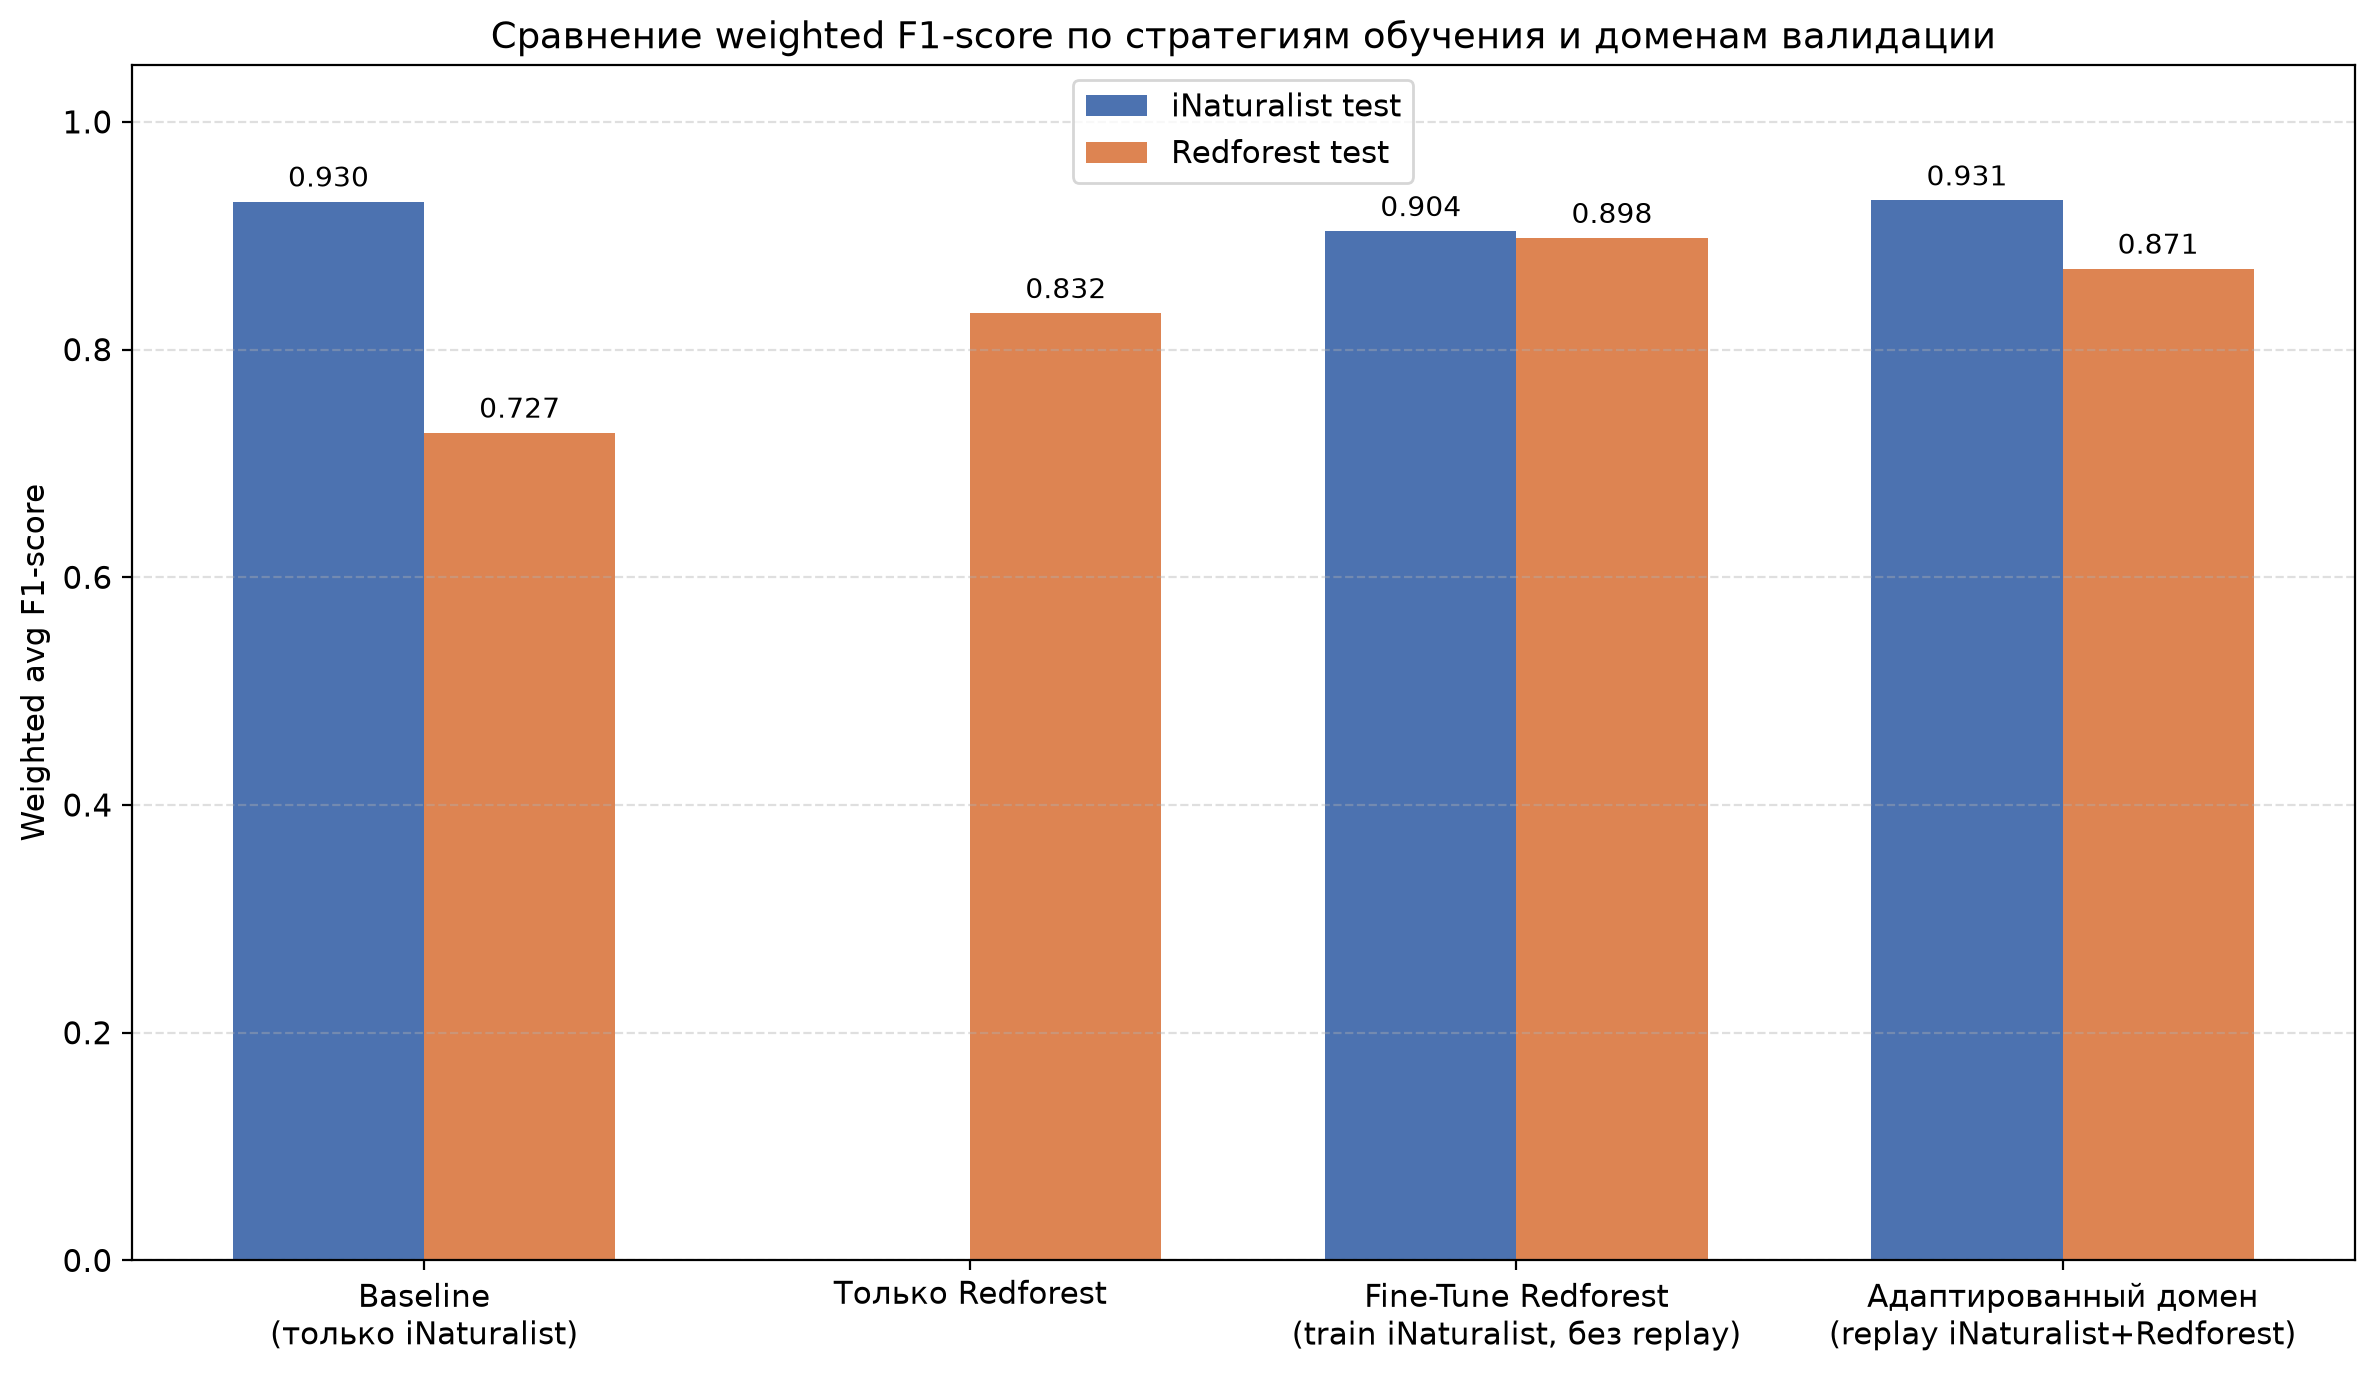

гипотеза подтверждена: модели, обученные только на iNaturalist, значительно теряют в качестве при переносе на снимки камер-ловушек. этот разрыв эффективно сокращается даже при небольшом объёме целевых данных RedForest. replay-дообучение (совместное использование исходного и целевого доменов) показало оптимальный баланс между адаптацией к новому домену и сохранением ранее выученных знаний — это делает подход предпочтительным для практических задач классификации фауны по снимкам камер-ловушек в условиях ограниченной доступности размеченных данных целевого региона